# Eksperimen Multi-Horizon Gold Price Prediction

**Tujuan**: Membandingkan 3 model ML (Linear Regression, Gradient Boosting, SVR) pada 5 horizon prediksi (1h, 12h, 24h, 48h, 72h) tanpa infrastruktur pipeline.

**Sumber data**: Yahoo Finance (730 hari historical hourly)

**Evaluasi**: GridSearchCV + TimeSeriesSplit(3) + MAE


In [ ]:
# 1: Setup & Imports
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

print("Imports OK")

Imports OK


In [ ]:
#Cell 2: Config — horizon, tickers, paths, feature columns
PREDICTION_HORIZONS = [1, 12, 24, 48, 72]
YF_PERIOD = "730d"
YF_INTERVAL = "1h"
LOOKBACK_HOURS = 168
TARGET_COLUMN = "gold_price"

TICKERS = {
    "gold_price": "GC=F",
    "oil_price": "CL=F",
    "dxy": "DX-Y.NYB",
    "eurusd": "EURUSD=X",
    "jpy": "JPY=X",
}

FEATURE_COLUMNS = [
    "lag_3", "lag_6", "lag_12", "lag_24", "lag_72", "lag_168",
    "rolling_mean_24", "rolling_std_24",
    "rolling_mean_72", "rolling_std_72",
    "rolling_mean_168", "rolling_std_168",
    "return_1h", "return_24h", "return_168h",
    "return_oil_24h", "return_dxy_24h", "return_eurusd_24h", "return_jpy_24h",
    "lag_1_oil", "lag_1_dxy", "lag_1_eurusd", "lag_1_jpy",
    "gold_dxy_ratio", "oil_dxy_ratio",
    "hour_of_day", "day_of_week",
]

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

RAW_PATH = DATA_DIR / "raw_hourly.parquet"
FEATURES_PATH = DATA_DIR / "features.parquet"

print(f"Feature columns: {len(FEATURE_COLUMNS)}")
print(f"Horizons: {PREDICTION_HORIZONS}")
print(f"Data cache: {DATA_DIR.resolve()}")

Feature columns: 27
Horizons: [1, 12, 24, 48, 72]
Data cache: /home/fatih/kuliah-projek/Gold-Prediction-Big-Data-Kel3/eksperiment/data


In [ ]:
# 3: compute_features() — self-contained copy dari shared/features.py
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("timestamp").reset_index(drop=True)
    result = df.copy()

    # Lag features
    result["lag_3"] = result["gold_price"].shift(3)
    result["lag_6"] = result["gold_price"].shift(6)
    result["lag_12"] = result["gold_price"].shift(12)
    result["lag_24"] = result["gold_price"].shift(24)
    result["lag_72"] = result["gold_price"].shift(72)
    result["lag_168"] = result["gold_price"].shift(168)

    # Rolling statistics
    result["rolling_mean_24"] = result["gold_price"].rolling(24, min_periods=1).mean()
    result["rolling_std_24"] = result["gold_price"].rolling(24, min_periods=1).std()
    result["rolling_mean_72"] = result["gold_price"].rolling(72, min_periods=1).mean()
    result["rolling_std_72"] = result["gold_price"].rolling(72, min_periods=1).std()
    result["rolling_mean_168"] = result["gold_price"].rolling(168, min_periods=1).mean()
    result["rolling_std_168"] = result["gold_price"].rolling(168, min_periods=1).std()

    # Returns
    result["return_1h"] = result["gold_price"].pct_change(1)
    result["return_24h"] = result["gold_price"].pct_change(24)
    result["return_168h"] = result["gold_price"].pct_change(168)
    result["return_oil_24h"] = result["oil_price"].pct_change(24)
    result["return_dxy_24h"] = result["dxy"].pct_change(24)
    result["return_eurusd_24h"] = result["eurusd"].pct_change(24)
    result["return_jpy_24h"] = result["jpy"].pct_change(24)

    # Cross-asset
    result["lag_1_oil"] = result["oil_price"].shift(1)
    result["lag_1_dxy"] = result["dxy"].shift(1)
    result["lag_1_eurusd"] = result["eurusd"].shift(1)
    result["lag_1_jpy"] = result["jpy"].shift(1)
    result["gold_dxy_ratio"] = result["gold_price"] / result["dxy"]
    result["oil_dxy_ratio"] = result["oil_price"] / result["dxy"]

    # Calendar
    timestamps = pd.to_datetime(result["timestamp"], utc=True, errors="coerce")
    if timestamps.isna().all():
        raise ValueError("No valid timestamps")
    result["hour_of_day"] = timestamps.dt.hour
    result["day_of_week"] = timestamps.dt.dayofweek

    return result

print("compute_features() defined")

In [ ]:
# 4: MODELS, PARAM_GRIDS, FEATURE_IMPORTANCE_MODELS

MODELS = {
    "linear_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ]),
    "gradient_boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", GradientBoostingRegressor(random_state=42)),
    ]),
    "svr": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR()),
    ]),
}

PARAM_GRIDS = {
    "linear_regression": {},
    "gradient_boosting": {
        "gbr__n_estimators": [50, 100, 200],
        "gbr__learning_rate": [0.05, 0.1],
        "gbr__max_depth": [3, 5],
    },
    "svr": {
        "svr__kernel": ["rbf", "linear"],
        "svr__C": [1, 50, 500],
        "svr__gamma": [0.001, 0.01, 0.1],
        "svr__epsilon": [0.1, 0.2, 0.5],
    },
}

FEATURE_IMPORTANCE_MODELS = {"gradient_boosting": "gbr"}

print("Models:", list(MODELS.keys()))
for name, grid in PARAM_GRIDS.items():
    if grid:
        kandidat = 1
        for v in grid.values():
            kandidat *= len(v)
        print(f"  {name}: {kandidat} GridSearchCV kandidat")
    else:
        print(f"  {name}: no GridSearchCV")

In [ ]:
#5: train_and_evaluate() & extract_feature_importance()

def extract_feature_importance(model, model_name):
    step_name = FEATURE_IMPORTANCE_MODELS.get(model_name)
    if not step_name:
        return {}
    estimator = model.named_steps.get(step_name)
    if not hasattr(estimator, "feature_importances_"):
        return {}
    importances = estimator.feature_importances_
    pairs = sorted(zip(FEATURE_COLUMNS, importances), key=lambda x: x[1], reverse=True)
    return {feat: round(float(imp), 6) for feat, imp in pairs}


def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test):
    param_grid = PARAM_GRIDS.get(model_name, {})
    if param_grid:
        tscv = TimeSeriesSplit(n_splits=3)
        search = GridSearchCV(
            model, param_grid,
            cv=tscv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = {k.split("__", 1)[-1]: v for k, v in search.best_params_.items()}
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = {}

    y_pred = best_model.predict(X_test)
    return {
        "model_name": model_name,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "r2": r2_score(y_test, y_pred),
        "model": best_model,
        "best_params": best_params,
        "feature_importance": extract_feature_importance(best_model, model_name),
    }

print("train_and_evaluate() & extract_feature_importance() defined")

In [ ]:
# 6: Fetch data dengan cache lokal

FORCE_DOWNLOAD = False  # set True untuk paksa download ulang

if FORCE_DOWNLOAD and RAW_PATH.exists():
    RAW_PATH.unlink()
    FEATURES_PATH.unlink()
    print("Cache dihapus")

if RAW_PATH.exists():
    print(f"Loading raw data from cache: {RAW_PATH}")
    df_raw = pd.read_parquet(RAW_PATH)
    print(f"Loaded {len(df_raw)} rows")
else:
    print("Downloading from Yahoo Finance...")
    ticker_str = " ".join(TICKERS.values())
    print(f"  Tickers: {ticker_str}")
    print(f"  Period: {YF_PERIOD}, Interval: {YF_INTERVAL}")

    raw = yf.download(
        ticker_str,
        period=YF_PERIOD,
        interval=YF_INTERVAL,
        progress=True,
    )

    data = {}
    for name, ticker in TICKERS.items():
        data[name] = raw["Close"].get(ticker, raw.get(("Close", ticker)))

    df_raw = pd.DataFrame(data).reset_index()
    df_raw = df_raw.rename(columns={
        "Date": "timestamp",
        "Datetime": "timestamp",
        "index": "timestamp",
    })
    df_raw["timestamp"] = df_raw["timestamp"].astype(str)
    df_raw = df_raw[[
        "timestamp", "gold_price", "oil_price", "dxy", "eurusd", "jpy",
    ]].dropna()

    df_raw.to_parquet(RAW_PATH)
    print(f"Saved to cache: {RAW_PATH}")

print(f"\nRaw data shape: {df_raw.shape}")
print(f"Date range: {df_raw['timestamp'].iloc[0]} → {df_raw['timestamp'].iloc[-1]}")
print(f"Gold price range: ${df_raw['gold_price'].min():.0f} – ${df_raw['gold_price'].max():.0f}")
df_raw.head()

Loading raw data from cache: data/raw_hourly.parquet
Loaded 13326 rows

Raw data shape: (13326, 6)
Date range: 2024-02-02 00:00:00-05:00 → 2026-06-26 16:00:00-04:00
Gold price range: $2000 – $5591


,timestamp,gold_price,oil_price,dxy,eurusd,jpy
2429,2024-02-02 00:00:00-05:00,2072.699951,74.029999,103.021004,1.088139,146.425995
2430,2024-02-02 01:00:00-05:00,2072.600098,74.110001,103.040001,1.087903,146.479996
2431,2024-02-02 02:00:00-05:00,2072.100098,74.169998,103.024002,1.088495,146.623001
2432,2024-02-02 03:00:00-05:00,2071.100098,73.779999,103.040001,1.088258,146.735992
2433,2024-02-02 04:00:00-05:00,2070.100098,74.209999,102.947998,1.089206,146.694000


In [ ]:
# 7: Feature engineering dengan cache

if FEATURES_PATH.exists() and not FORCE_DOWNLOAD:
    print(f"Loading features from cache: {FEATURES_PATH}")
    df_features = pd.read_parquet(FEATURES_PATH)
    print(f"Loaded {len(df_features)} rows, {len(df_features.columns)} columns")
else:
    print(f"Computing features from {len(df_raw)} rows...")
    df_features = compute_features(df_raw)
    df_features = df_features.dropna(subset=FEATURE_COLUMNS).reset_index(drop=True)
    df_features.to_parquet(FEATURES_PATH)
    print(f"Saved to cache: {FEATURES_PATH}")

print(f"\nFeature table: {df_features.shape[0]} rows x {df_features.shape[1]} cols")
print(f"Target range: ${df_features[TARGET_COLUMN].min():.0f} – ${df_features[TARGET_COLUMN].max():.0f}")
print(f"Null values in features: {df_features[FEATURE_COLUMNS].isnull().sum().sum()}")
df_features[FEATURE_COLUMNS].describe().T.style.background_gradient(cmap="Blues")

Loading features from cache: data/features.parquet
Loaded 13158 rows, 33 columns

Feature table: 13158 rows x 33 cols
Target range: $2000 – $5591
Null values in features: 0


,count,mean,std,min,25%,50%,75%,max
lag_3,13158.000000,3346.814798,907.277677,1999.900024,2586.349976,3243.899902,4145.699829,5591.000000
lag_6,13158.000000,3346.345464,907.421082,1999.900024,2584.425049,3243.750000,4145.699829,5591.000000
lag_12,13158.000000,3345.414791,907.719504,1999.900024,2581.749939,3242.599976,4145.699829,5591.000000
lag_24,13158.000000,3343.589840,908.346177,1999.900024,2575.449951,3240.799927,4145.699829,5591.000000
lag_72,13158.000000,3336.281229,910.718671,1999.900024,2560.325012,3233.099976,4145.699829,5591.000000
lag_168,13158.000000,3320.220171,913.826696,1999.900024,2547.800049,3186.599976,4122.374878,5591.000000
rolling_mean_24,13158.000000,3345.501393,907.392008,2003.887502,2582.018748,3244.412501,4146.406247,5492.074951
rolling_std_24,13158.000000,17.132705,17.188806,1.781750,7.140958,11.919890,20.699822,227.314302
rolling_mean_72,13158.000000,3341.861589,907.994858,2009.056944,2580.936460,3248.820133,4159.607980,5310.597229
rolling_std_72,13158.000000,30.786342,28.088565,2.807835,13.725571,22.037595,37.545673,273.344620


In [ ]:
# 8: Training loop — semua horizon × semua model
from tqdm.notebook import tqdm

timestamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
all_results = []
champions = {}
importance_by_horizon = {}

total_runs = len(PREDICTION_HORIZONS) * len(MODELS)
pbar = tqdm(total=total_runs, desc="Training", unit="model")

for horizon in PREDICTION_HORIZONS:
    target = df_features[TARGET_COLUMN].shift(-horizon)
    valid_idx = target.dropna().index

    X = df_features.loc[valid_idx, FEATURE_COLUMNS]
    y = target.loc[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False,
    )

    horizon_results = []
    for name, model_pipeline in MODELS.items():
        pbar.set_postfix_str(f"h={horizon} {name}")
        result = train_and_evaluate(
            model_pipeline, name,
            X_train, X_test, y_train, y_test,
        )
        result["horizon"] = horizon
        result["n_train"] = len(X_train)
        result["n_test"] = len(X_test)
        horizon_results.append(result)
        pbar.update(1)

    best = min(horizon_results, key=lambda r: r["mae"])
    champions[horizon] = {
        "model": best["model_name"],
        "mae": best["mae"],
        "rmse": best["rmse"],
        "r2": best["r2"],
        "best_params": best["best_params"],
    }

    if best.get("feature_importance"):
        importance_by_horizon[horizon] = best["feature_importance"]

    all_results.extend(horizon_results)

pbar.close()
print(f"\nTraining selesai — {len(all_results)} model runs ({total_runs} expected)")
print(f"Timestamp: {timestamp}")

In [ ]:
# 9: Results table — perbandingan per horizon × per model

rows = []
for r in all_results:
    rows.append({
        "Horizon": f"{r['horizon']}h",
        "Model": r["model_name"],
        "MAE": round(r["mae"], 4),
        "RMSE": round(r["rmse"], 4),
        "R²": round(r["r2"], 4),
        "Train Rows": r["n_train"],
        "Test Rows": r["n_test"],
    })

df_results = pd.DataFrame(rows)

def highlight_champion(row):
    h = int(row["Horizon"].rstrip("h"))
    if row["Model"] == champions[h]["model"]:
        return ["background-color: #d4edda"] * len(row)
    return [""] * len(row)

styled = (
    df_results.style
    .apply(highlight_champion, axis=1)
    .format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R²": "{:.4f}"})
    .set_caption("Perbandingan Model per Horizon — hijau = champion")
)
display(styled)

print("\n--- CHAMPIONS PER HORIZON ---")
for h, c in champions.items():
    print(f"  h={h:>2d}: {c['model']:<20s}  MAE={c['mae']:.2f}  R²={c['r2']:.4f}")

In [ ]:
# 10: Visualisasi — MAE/R² per horizon, feature importance

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Plot 1: MAE per model × horizon ----
ax = axes[0, 0]
for model_name in MODELS:
    subset = df_results[df_results["Model"] == model_name]
    ax.plot(subset["Horizon"], subset["MAE"], marker="o", label=model_name)
ax.set_xlabel("Horizon")
ax.set_ylabel("MAE (USD)")
ax.set_title("MAE per Horizon per Model (lower = better)")
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Plot 2: R² per model × horizon ----
ax = axes[0, 1]
for model_name in MODELS:
    subset = df_results[df_results["Model"] == model_name]
    ax.plot(subset["Horizon"], subset["R²"], marker="s", label=model_name)
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5, label="R²=0")
ax.set_xlabel("Horizon")
ax.set_ylabel("R² Score")
ax.set_title("R² per Horizon per Model (higher = better)")
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Plot 3: Champion MAE trend ----
ax = axes[1, 0]
champ_horizons = [f"{h}h" for h in champions]
champ_mae = [c["mae"] for c in champions.values()]
champ_labels = [f"{h}\
({c['model']})" for h, c in champions.items()]
ax.bar(range(len(champ_horizons)), champ_mae, color="steelblue", edgecolor="navy")
ax.set_xticks(range(len(champ_horizons)))
ax.set_xticklabels(champ_labels)
ax.set_ylabel("MAE (USD)")
ax.set_title("Champion MAE per Horizon")
ax.grid(True, alpha=0.3, axis="y")

# ---- Plot 4: Feature importance (averaged over GBR runs) ----
ax = axes[1, 1]
if importance_by_horizon:
    avg_importance = {}
    for h, imp_dict in importance_by_horizon.items():
        for feat, imp in imp_dict.items():
            avg_importance[feat] = avg_importance.get(feat, 0) + imp
    for feat in avg_importance:
        avg_importance[feat] /= len(importance_by_horizon)

    sorted_imp = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:15]
    feats, imps = zip(*sorted_imp)
    colors = ["#2ca02c" if imp > 0.05 else "#1f77b4" for imp in imps]
    ax.barh(range(len(feats)), imps, color=colors)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats)
    ax.invert_yaxis()
    ax.set_xlabel("Average Importance")
    ax.set_title("GBR Feature Importance (avg across horizons)")
    ax.grid(True, alpha=0.3, axis="x")
else:
    ax.text(0.5, 0.5, "No feature importance data", ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
# 11: Save results ke JSON

output = {
    "timestamp": timestamp,
    "config": {
        "horizons": PREDICTION_HORIZONS,
        "n_features": len(FEATURE_COLUMNS),
        "features": FEATURE_COLUMNS,
        "models": list(MODELS.keys()),
        "yf_period": YF_PERIOD,
        "yf_interval": YF_INTERVAL,
    },
    "champions": {str(k): v for k, v in champions.items()},
    "all_results": all_results,
}

output_path = RESULTS_DIR / f"results_{timestamp}.json"
with open(output_path, "w") as f:
    json.dump(output, f, indent=2, default=str)

latest_link = RESULTS_DIR / "latest.json"
if latest_link.is_symlink() or latest_link.exists():
    latest_link.unlink()
latest_link.symlink_to(output_path.name)

print(f"Results saved to {output_path}")
print(f"Linked as {latest_link}")

In [ ]:
# 12: Quick summary (run after training)

print("=" * 65)
print("  EXPERIMENT SUMMARY")
print("=" * 65)
print(f"  Data: {len(df_features)} rows × {len(FEATURE_COLUMNS)} features")
print(f"  Horizons: {PREDICTION_HORIZONS}")
print(f"  Models: {list(MODELS.keys())}")
print(f"  Date range: {df_features['timestamp'].iloc[0]} → {df_features['timestamp'].iloc[-1]}")
print()

# Per-hitungan rata-rata MAE per model type
print("  AVERAGE MAE PER MODEL TYPE (across all horizons):")
for model_name in MODELS:
    subset = df_results[df_results["Model"] == model_name]
    avg_mae = subset["MAE"].mean()
    avg_r2 = subset["R²"].mean()
    print(f"    {model_name:<22s}  avg MAE={avg_mae:.2f}  avg R²={avg_r2:.4f}")

print()
print("  OVERALL CHAMPION COUNT:")
counts = pd.Series([c["model"] for c in champions.values()]).value_counts()
for model, count in counts.items():
    print(f"    {model}: {count} horizons")

print()
print(f"  Results saved to: {output_path}")
print("=" * 65)

---
# EKSPERIMEN TAMBAHAN: GBR + RandomizedSearchCV
---


In [ ]:
# 13: RandomizedSearchCV — imports, fungsi, param dist
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

GBR_PARAM_DIST = {
    "gbr__n_estimators":       randint(100, 500),
    "gbr__learning_rate":      uniform(0.01, 0.3),
    "gbr__max_depth":          randint(3, 10),
    "gbr__subsample":          uniform(0.5, 0.5),
    "gbr__min_samples_split":  randint(2, 20),
    "gbr__min_samples_leaf":   randint(1, 10),
    "gbr__max_features":       ["sqrt", "log2", None],
    "gbr__loss":               ["squared_error", "huber", "absolute_error"],
}

N_ITER_RANDOM = 100  # jumlah kombinasi acak yang dicoba per horizon


FEATURE_IMPORTANCE_MODELS = {"gradient_boosting": "gbr"}


def extract_feature_importance(model, model_name):
    step_name = FEATURE_IMPORTANCE_MODELS.get(model_name)
    if not step_name:
        return {}
    estimator = model.named_steps.get(step_name)
    if not hasattr(estimator, "feature_importances_"):
        return {}
    importances = estimator.feature_importances_
    pairs = sorted(zip(FEATURE_COLUMNS, importances), key=lambda x: x[1], reverse=True)
    return {feat: round(float(imp), 6) for feat, imp in pairs}


def train_and_evaluate_randomized(model, model_name, X_train, X_test, y_train, y_test,
                                   param_dist, n_iter):
    tscv = TimeSeriesSplit(n_splits=3)
    search = RandomizedSearchCV(
        model, param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=42,
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_params = {k.split("__", 1)[-1]: v for k, v in search.best_params_.items()}

    y_pred = best_model.predict(X_test)
    return {
        "model_name": model_name,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "r2": r2_score(y_test, y_pred),
        "model": best_model,
        "best_params": best_params,
        "feature_importance": extract_feature_importance(best_model, model_name),
    }


print("RandomizedSearchCV ready")
print(f"n_iter={N_ITER_RANDOM}, 3-fold CV -> {N_ITER_RANDOM * 3} fits per horizon")

RandomizedSearchCV ready
n_iter=100, 3-fold CV -> 300 fits per horizon


In [ ]:
#14: Training loop — GBR + RandomizedSearchCV x 5 horizon
from tqdm.notebook import tqdm

timestamp_rand = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
all_results_rand = []
best_params_by_horizon = {}

pbar = tqdm(total=len(PREDICTION_HORIZONS), desc="GBR Randomized", unit="horizon")

for horizon in PREDICTION_HORIZONS:
    target = df_features[TARGET_COLUMN].shift(-horizon)
    valid_idx = target.dropna().index

    X = df_features.loc[valid_idx, FEATURE_COLUMNS]
    y = target.loc[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False,
    )

    gbr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", GradientBoostingRegressor(random_state=42)),
    ])

    pbar.set_postfix_str(f"h={horizon}")
    result = train_and_evaluate_randomized(
        gbr_pipe, "gradient_boosting",
        X_train, X_test, y_train, y_test,
        GBR_PARAM_DIST, N_ITER_RANDOM,
    )
    result["horizon"] = horizon
    result["n_train"] = len(X_train)
    result["n_test"] = len(X_test)
    all_results_rand.append(result)

    best_params_by_horizon[horizon] = result["best_params"]
    pbar.update(1)

pbar.close()

print("\nTraining selesai")
for h in PREDICTION_HORIZONS:
    r = [x for x in all_results_rand if x["horizon"] == h][0]
    print(f"  h={h:>2d}:  MAE={r['mae']:.2f}  R\u00b2={r['r2']:.4f}")

In [ ]:
# 15: Results — best params + metrics + feature importance

print("=" * 65)
print("  GBR RandomizedSearchCV RESULTS")
print("=" * 65)

rows_rand = []
for r in all_results_rand:
    rows_rand.append({
        "Horizon": f"{r['horizon']}h",
        "MAE": round(r["mae"], 2),
        "RMSE": round(r["rmse"], 2),
        "R\u00b2": round(r["r2"], 4),
        "n_train": r["n_train"],
        "n_test": r["n_test"],
    })
df_rand = pd.DataFrame(rows_rand)
display(df_rand.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R\u00b2": "{:.4f}"}))

print()
for h in PREDICTION_HORIZONS:
    r = [x for x in all_results_rand if x["horizon"] == h][0]
    print(f"\n--- Horizon {h}h ---")
    print(f"  Best params:")
    for k, v in r["best_params"].items():
        if isinstance(v, float):
            print(f"    {k}: {v:.6f}")
        else:
            print(f"    {k}: {v}")
    if r["feature_importance"]:
        top5 = sorted(r["feature_importance"].items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"  Top-5 features:")
        for feat, imp in top5:
            print(f"    {feat}: {imp:.6f}")

In [ ]:
# 16: Perbandingan GridSearchCV vs RandomizedSearchCV
comp_rows = []
for h in PREDICTION_HORIZONS:
    orig = [r for r in all_results
            if r["horizon"] == h and r["model_name"] == "gradient_boosting"]
    rand = [r for r in all_results_rand if r["horizon"] == h]
    comp_rows.append({
        "Horizon": f"{h}h",
        "MAE (Grid)": round(orig[0]["mae"], 2),
        "R\u00b2 (Grid)": round(orig[0]["r2"], 4),
        "MAE (Random)": round(rand[0]["mae"], 2),
        "R\u00b2 (Random)": round(rand[0]["r2"], 4),
    })

df_comp = pd.DataFrame(comp_rows)
display(df_comp.style.format({
    "MAE (Grid)": "{:.2f}", "MAE (Random)": "{:.2f}",
    "R\u00b2 (Grid)": "{:.4f}", "R\u00b2 (Random)": "{:.4f}",
}))

In [ ]:

# 17: Save hasil randomized ke JSON

output_rand = {
    "timestamp": timestamp_rand,
    "method": "RandomizedSearchCV",
    "n_iter": N_ITER_RANDOM,
    "config": {
        "horizons": PREDICTION_HORIZONS,
        "n_features": len(FEATURE_COLUMNS),
        "yf_period": YF_PERIOD,
    },
    "param_distributions": {
        "gbr__n_estimators": "randint(100, 500)",
        "gbr__learning_rate": "uniform(0.01, 0.3)",
        "gbr__max_depth": "randint(3, 10)",
        "gbr__subsample": "uniform(0.5, 0.5)",
        "gbr__min_samples_split": "randint(2, 20)",
        "gbr__min_samples_leaf": "randint(1, 10)",
        "gbr__max_features": ["sqrt", "log2", None],
        "gbr__loss": ["squared_error", "huber", "absolute_error"],
    },
    "best_params_per_horizon": {str(k): v for k, v in best_params_by_horizon.items()},
    "all_results": all_results_rand,
}

output_path_rand = RESULTS_DIR / f"results_gbr_random_{timestamp_rand}.json"
with open(output_path_rand, "w") as f:
    json.dump(output_rand, f, indent=2, default=str)

print(f"Saved to {output_path_rand}")

---
# SAVE MODELS
---


In [ ]:
# 18: Save semua fitted model ke disk (joblib)
import joblib

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

saved_models = []

# Save GridSearchCV models
for r in all_results:
    fname = f"{r['model_name']}_h{r['horizon']}_{timestamp}.joblib"
    path = MODELS_DIR / fname
    joblib.dump(r["model"], path)
    saved_models.append(path)
    print(f"Saved {fname}")

print()

# Save RandomizedSearchCV models (GBR only)
for r in all_results_rand:
    fname = f"{r['model_name']}_h{r['horizon']}_random_{timestamp_rand}.joblib"
    path = MODELS_DIR / fname
    joblib.dump(r["model"], path)
    saved_models.append(path)
    print(f"Saved {fname}")

print(f"\nTotal models saved: {len(saved_models)} to {MODELS_DIR.resolve()}")

NameError: name 'timestamp' is not defined

---
# EKSPERIMEN TAMBAHAN: SVR + RandomizedSearchCV
---


In [ ]:
# 19: SVR (LinearSVR) param distributions
from scipy.stats import uniform
from sklearn.svm import LinearSVR

SVR_PARAM_DIST = {
    "svr__C":       uniform(0.01, 100),
    "svr__epsilon": uniform(0.01, 0.5),
    "svr__loss":    ["epsilon_insensitive", "squared_epsilon_insensitive"],
}

N_ITER_SVR = 50

print("LinearSVR param dist ready")
print(f"n_iter={N_ITER_SVR}, 3-fold CV -> {N_ITER_SVR * 3} fits per horizon")

LinearSVR param dist ready
n_iter=50, 3-fold CV -> 150 fits per horizon


In [ ]:
# 20: Training loop — SVR + RandomizedSearchCV x 5 horizon
from tqdm.notebook import tqdm

timestamp_svr_rand = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
all_results_svr_rand = []
best_params_svr_by_horizon = {}

pbar = tqdm(total=len(PREDICTION_HORIZONS), desc="SVR Randomized", unit="horizon")

for horizon in PREDICTION_HORIZONS:
    target = df_features[TARGET_COLUMN].shift(-horizon)
    valid_idx = target.dropna().index

    X = df_features.loc[valid_idx, FEATURE_COLUMNS]
    y = target.loc[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False,
    )

    svr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", LinearSVR(random_state=42, dual="auto", max_iter=20000)),
    ])

    pbar.set_postfix_str(f"h={horizon}")
    result = train_and_evaluate_randomized(
        svr_pipe, "svr",
        X_train, X_test, y_train, y_test,
        SVR_PARAM_DIST, N_ITER_SVR,
    )
    result["horizon"] = horizon
    result["n_train"] = len(X_train)
    result["n_test"] = len(X_test)
    all_results_svr_rand.append(result)

    best_params_svr_by_horizon[horizon] = result["best_params"]
    pbar.update(1)

pbar.close()

print("\nTraining selesai")
for h in PREDICTION_HORIZONS:
    r = [x for x in all_results_svr_rand if x["horizon"] == h][0]
    print(f"  h={h:>2d}:  MAE={r['mae']:.2f}  R\u00b2={r['r2']:.4f}")

SVR Randomized:   0%|          | 0/5 [00:00<?, ?horizon/s]

/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  


Training selesai
  h= 1:  MAE=19.58  R²=0.9911
  h=12:  MAE=53.26  R²=0.9384
  h=24:  MAE=86.29  R²=0.8647
  h=48:  MAE=147.79  R²=0.6598
  h=72:  MAE=190.11  R²=0.4621


In [ ]:
#21: Results — best params + metrics per horizon

print("=" * 65)
print("  SVR RandomizedSearchCV RESULTS")
print("=" * 65)

rows_svr = []
for r in all_results_svr_rand:
    rows_svr.append({
        "Horizon": f"{r['horizon']}h",
        "MAE": round(r["mae"], 2),
        "RMSE": round(r["rmse"], 2),
        "R\u00b2": round(r["r2"], 4),
        "n_train": r["n_train"],
        "n_test": r["n_test"],
    })
df_svr = pd.DataFrame(rows_svr)
display(df_svr.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R\u00b2": "{:.4f}"}))

print()
for h in PREDICTION_HORIZONS:
    r = [x for x in all_results_svr_rand if x["horizon"] == h][0]
    print(f"\n--- Horizon {h}h ---")
    print(f"  Best params:")
    for k, v in r["best_params"].items():
        if isinstance(v, float):
            print(f"    {k}: {v:.6f}")
        else:
            print(f"    {k}: {v}")

  SVR RandomizedSearchCV RESULTS


,Horizon,MAE,RMSE,R²,n_train,n_test
0,1h,19.58,29.68,0.9911,10525,2632
1,12h,53.26,78.20,0.9384,10516,2630
2,24h,86.29,115.95,0.8647,10507,2627
3,48h,147.79,183.95,0.6598,10488,2622
4,72h,190.11,231.37,0.4621,10468,2618




--- Horizon 1h ---
  Best params:
    C: 93.865271
    epsilon: 0.010389
    loss: squared_epsilon_insensitive

--- Horizon 12h ---
  Best params:
    C: 37.464012
    epsilon: 0.485357
    loss: epsilon_insensitive

--- Horizon 24h ---
  Best params:
    C: 92.197424
    epsilon: 0.054246
    loss: epsilon_insensitive

--- Horizon 48h ---
  Best params:
    C: 66.262228
    epsilon: 0.165856
    loss: squared_epsilon_insensitive

--- Horizon 72h ---
  Best params:
    C: 17.346465
    epsilon: 0.205530
    loss: squared_epsilon_insensitive


In [21]:
import json 
with open("results/results_20260627_061746.json") as f:
    all_results = json.load(f)["all_results"]
print(f"loaded {len(all_results)} results from old gridsearchcv")

loaded 15 results from old gridsearchcv


In [ ]:
# 22: SVR GridSearchCV vs RandomizedSearchCV

comp_svr_rows = []
for h in PREDICTION_HORIZONS:
    orig = [r for r in all_results
            if r["horizon"] == h and r["model_name"] == "svr"]
    rand = [r for r in all_results_svr_rand if r["horizon"] == h]
    comp_svr_rows.append({
        "Horizon": f"{h}h",
        "MAE (Grid)": round(orig[0]["mae"], 2),
        "R\u00b2 (Grid)": round(orig[0]["r2"], 4),
        "MAE (Random)": round(rand[0]["mae"], 2),
        "R\u00b2 (Random)": round(rand[0]["r2"], 4),
    })

df_comp_svr = pd.DataFrame(comp_svr_rows)
display(df_comp_svr.style.format({
    "MAE (Grid)": "{:.2f}", "MAE (Random)": "{:.2f}",
    "R\u00b2 (Grid)": "{:.4f}", "R\u00b2 (Random)": "{:.4f}",
}))

,Horizon,MAE (Grid),R² (Grid),MAE (Random),R² (Random)
0,1h,22.39,0.9882,19.58,0.9911
1,12h,56.42,0.9334,53.26,0.9384
2,24h,87.30,0.8622,86.29,0.8647
3,48h,120.63,0.7505,147.79,0.6598
4,72h,144.76,0.6555,190.11,0.4621


In [ ]:
#23: Save SVR randomized results + models
from pathlib import Path
import joblib

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

output_svr_rand = {
    "timestamp": timestamp_svr_rand,
    "method": "RandomizedSearchCV",
    "model": "svr",
    "n_iter": N_ITER_SVR,
    "config": {
        "horizons": PREDICTION_HORIZONS,
        "n_features": len(FEATURE_COLUMNS),
        "yf_period": YF_PERIOD,
    },
    "param_distributions": {
        "model": "LinearSVR",
        "svr__C": "uniform(0.01, 100)",
        "svr__epsilon": "uniform(0.01, 0.5)",
        "svr__loss": ["epsilon_insensitive", "squared_epsilon_insensitive"],
        "svr__max_iter": 20000,
    },
    "best_params_per_horizon": {str(k): v for k, v in best_params_svr_by_horizon.items()},
    "all_results": all_results_svr_rand,
}

output_path_svr_rand = RESULTS_DIR / f"results_svr_random_{timestamp_svr_rand}.json"
with open(output_path_svr_rand, "w") as f:
    json.dump(output_svr_rand, f, indent=2, default=str)

print(f"Saved to {output_path_svr_rand}")

# Save SVR randomized models
for r in all_results_svr_rand:
    fname = f"{r['model_name']}_h{r['horizon']}_svr_random_{timestamp_svr_rand}.joblib"
    path = MODELS_DIR / fname
    joblib.dump(r["model"], path)
    print(f"Saved {fname}")

Saved to results/results_svr_random_20260627_103333.json
Saved svr_h1_svr_random_20260627_103333.joblib
Saved svr_h12_svr_random_20260627_103333.joblib
Saved svr_h24_svr_random_20260627_103333.joblib
Saved svr_h48_svr_random_20260627_103333.joblib
Saved svr_h72_svr_random_20260627_103333.joblib


---
# VISUALISASI LENGKAP
---


In [ ]:

#24: Comprehensive Visualization
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path("results")

with open(RESULTS_DIR / "results_20260627_091700.json") as f:
    data_grid = json.load(f)
with open(RESULTS_DIR / "results_gbr_random_20260627_093439.json") as f:
    data_gbr_rand = json.load(f)
with open(RESULTS_DIR / "results_svr_random_20260627_103333.json") as f:
    data_svr_rand = json.load(f)

all_grid = data_grid["all_results"]
all_gbr = data_gbr_rand["all_results"]
all_svr = data_svr_rand["all_results"]
champions = data_grid["champions"]

HORIZONS = [1, 12, 24, 48, 72]
MODEL_LABELS = {
    "linear_regression": "Linear Regression",
    "gradient_boosting": "Gradient Boosting",
    "svr": "SVR",
}
MODEL_COLORS = {
    "linear_regression": "#2ca02c",
    "gradient_boosting": "#d62728",
    "svr": "#1f77b4",
}

print("All data loaded")

All data loaded


In [ ]:
rows = []
for r in all_grid:
    rows.append({
        "Horizon": f"{r['horizon']}h",
        "Model": MODEL_LABELS[r["model_name"]],
        "MAE": round(r["mae"], 2),
        "RMSE": round(r["rmse"], 2),
        "R\u00b2": round(r["r2"], 4),
        "Train": r["n_train"],
        "Test": r["n_test"],
    })

df_all = pd.DataFrame(rows)

def highlight_champion(row):
    h = int(row["Horizon"].rstrip("h"))
    if row["Model"] == MODEL_LABELS[champions[str(h)]["model"]]:
        return ["background-color: #d4edda; font-weight: bold"] * len(row)
    return [""] * len(row)

print("=" * 75)
print("  TABLE 1  |  GridSearchCV — Semua Model \u00d7 Semua Horizon")
print("  Hijau = champion model untuk horizon tersebut")
print("=" * 75)

display(
    df_all.style.apply(highlight_champion, axis=1)
    .format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R\u00b2": "{:.4f}"})
    .set_caption("GridSearchCV Results — Hijau = Champion")
)

  TABLE 1  |  GridSearchCV — Semua Model × Semua Horizon
  Hijau = champion model untuk horizon tersebut


,Horizon,Model,MAE,RMSE,R²,Train,Test
0,1h,Linear Regression,18.16,28.41,0.9919,10525,2632
1,1h,Gradient Boosting,277.68,372.10,-0.3941,10525,2632
2,1h,SVR,22.39,34.29,0.9882,10525,2632
3,12h,Linear Regression,59.94,83.29,0.9302,10516,2630
4,12h,Gradient Boosting,368.49,462.56,-1.1535,10516,2630
5,12h,SVR,56.42,81.36,0.9334,10516,2630
6,24h,Linear Regression,95.41,124.89,0.8431,10507,2627
7,24h,Gradient Boosting,420.66,508.10,-1.5972,10507,2627
8,24h,SVR,86.17,115.74,0.8652,10507,2627
9,48h,Linear Regression,149.13,185.49,0.6541,10488,2622


In [ ]:
# Tabel 2: Satu Model di Semua Horizon (GridSearchCV)

for model in ["linear_regression", "svr", "gradient_boosting"]:
    label = MODEL_LABELS[model]
    subset = df_all[df_all["Model"] == label][["Horizon", "MAE", "RMSE", "R\u00b2"]]
    print(f"\n{'=' * 50}")
    print(f"  {label}")
    print(f"{'=' * 50}")
    display(
        subset.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R\u00b2": "{:.4f}"})
        .set_caption(f"{label} — Evolusi per Horizon")
    )


  Linear Regression


,Horizon,MAE,RMSE,R²
0,1h,18.16,28.41,0.9919
3,12h,59.94,83.29,0.9302
6,24h,95.41,124.89,0.8431
9,48h,149.13,185.49,0.6541
12,72h,197.07,238.78,0.4271



  SVR


,Horizon,MAE,RMSE,R²
2,1h,22.39,34.29,0.9882
5,12h,56.42,81.36,0.9334
8,24h,86.17,115.74,0.8652
11,48h,120.63,157.53,0.7505
14,72h,144.76,185.15,0.6555



  Gradient Boosting


,Horizon,MAE,RMSE,R²
1,1h,277.68,372.10,-0.3941
4,12h,368.49,462.56,-1.1535
7,24h,420.66,508.10,-1.5972
10,48h,444.30,535.31,-1.8810
13,72h,496.95,582.36,-2.4080


In [ ]:
# Tabel 3: Perbandingan GridSearchCV vs RandomizedSearchCV

comp_rows = []

for model_key, all_rand_list in [("gradient_boosting", all_gbr), ("svr", all_svr)]:
    label = MODEL_LABELS[model_key]
    for h in HORIZONS:
        orig = [r for r in all_grid if r["model_name"] == model_key and r["horizon"] == h]
        rand = [r for r in all_rand_list if r["horizon"] == h]
        o, r = orig[0], rand[0]
        delta_mae = round(r["mae"] - o["mae"], 2)
        delta_r2 = round(r["r2"] - o["r2"], 4)
        comp_rows.append({
            "Model": label,
            "Horizon": f"{h}h",
            "MAE Grid": round(o["mae"], 2),
            "MAE Random": round(r["mae"], 2),
            "\u0394 MAE": delta_mae,
            "R\u00b2 Grid": round(o["r2"], 4),
            "R\u00b2 Random": round(r["r2"], 4),
            "\u0394 R\u00b2": delta_r2,
        })

df_comp = pd.DataFrame(comp_rows)

print("=" * 80)
print("  TABLE 3  |  GridSearchCV vs RandomizedSearchCV")
print("  \u0394 MAE negatif (hijau) = Random lebih baik |  \u0394 MAE positif (merah) = Random lebih buruk")
print("=" * 80)

styled = df_comp.style.format({
    "MAE Grid": "{:.2f}", "MAE Random": "{:.2f}", "\u0394 MAE": "{:+.2f}",
    "R\u00b2 Grid": "{:.4f}", "R\u00b2 Random": "{:.4f}", "\u0394 R\u00b2": "{:+.4f}",
})

def color_delta_mae(val):
    if val < 0:
        return "color: green; font-weight: bold"
    elif val > 0:
        return "color: red"
    return ""

styled = styled.map(color_delta_mae, subset=["\u0394 MAE"])
styled = styled.map(color_delta_mae, subset=["\u0394 R\u00b2"])
display(styled.set_caption("Grid vs Random — Hijau = Improvement dari Randomized"))

  TABLE 3  |  GridSearchCV vs RandomizedSearchCV
  Δ MAE negatif (hijau) = Random lebih baik |  Δ MAE positif (merah) = Random lebih buruk


,Model,Horizon,MAE Grid,MAE Random,Δ MAE,R² Grid,R² Random,Δ R²
0,Gradient Boosting,1h,277.68,257.78,-19.91,-0.3941,-0.2243,+0.1697
1,Gradient Boosting,12h,368.49,374.09,+5.60,-1.1535,-1.2015,-0.0480
2,Gradient Boosting,24h,420.66,399.38,-21.28,-1.5972,-1.3495,+0.2477
3,Gradient Boosting,48h,444.30,622.82,+178.52,-1.8810,-3.8326,-1.9516
4,Gradient Boosting,72h,496.95,558.71,+61.75,-2.4080,-3.2080,-0.8000
5,SVR,1h,22.39,19.58,-2.81,0.9882,0.9911,+0.0030
6,SVR,12h,56.42,53.26,-3.16,0.9334,0.9384,+0.0051
7,SVR,24h,86.17,86.29,+0.12,0.8652,0.8647,-0.0005
8,SVR,48h,120.63,147.79,+27.16,0.7505,0.6598,-0.0907
9,SVR,72h,144.76,190.11,+45.35,0.6555,0.4621,-0.1935


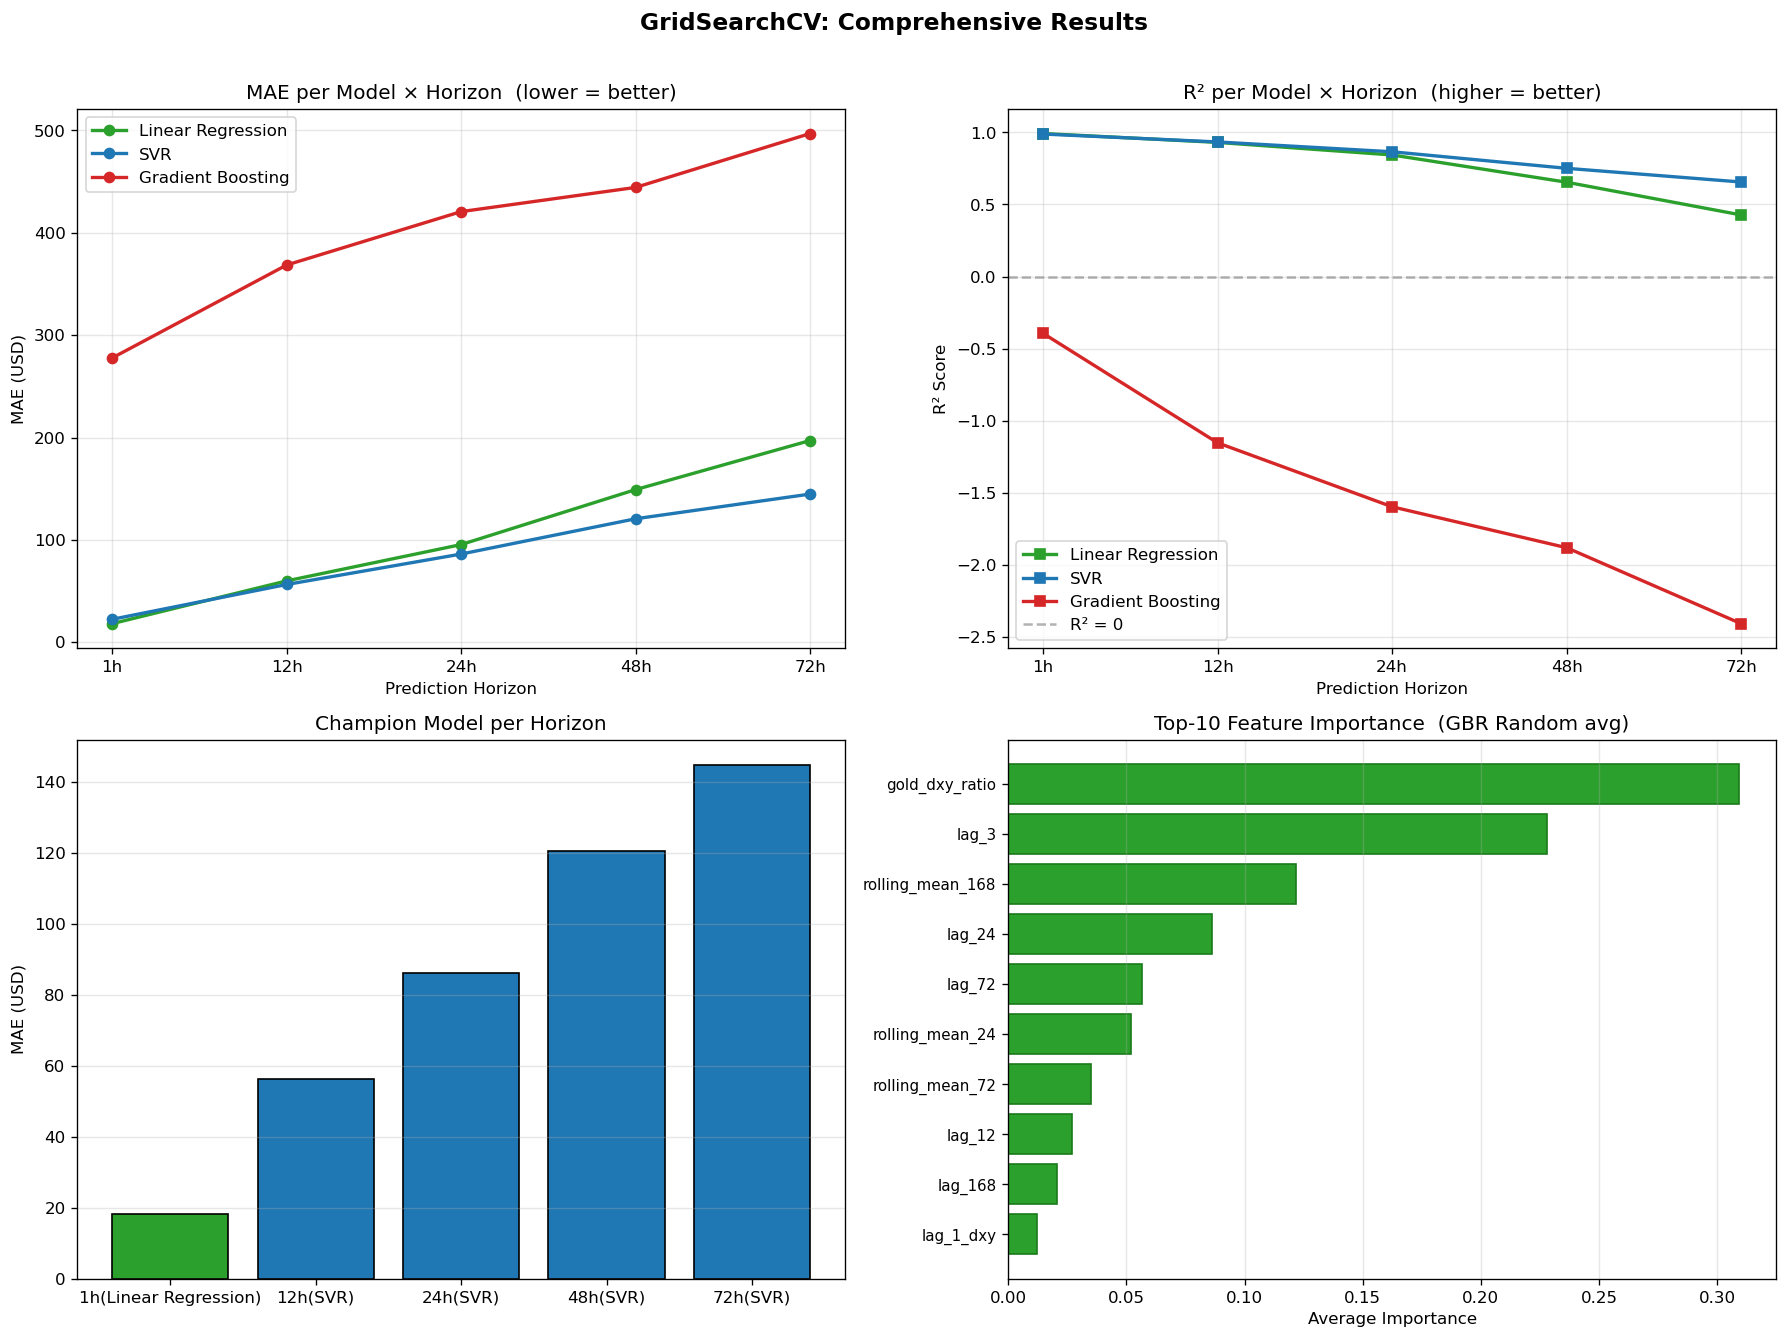

In [ ]:

# Plot 1: MAE & R\u00b2 per Model \u00d7 Horizon + Champions + Feature Importance

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (0,0) MAE per model x horizon
ax = axes[0, 0]
for model_key in ["linear_regression", "svr", "gradient_boosting"]:
    label = MODEL_LABELS[model_key]
    subset = df_all[df_all["Model"] == label]
    ax.plot(subset["Horizon"], subset["MAE"], marker="o", linewidth=2,
            color=MODEL_COLORS[model_key], label=label)
ax.set_xlabel("Prediction Horizon")
ax.set_ylabel("MAE (USD)")
ax.set_title("MAE per Model \u00d7 Horizon  (lower = better)")
ax.legend()
ax.grid(True, alpha=0.3)

# (0,1) R\u00b2 per model x horizon
ax = axes[0, 1]
for model_key in ["linear_regression", "svr", "gradient_boosting"]:
    label = MODEL_LABELS[model_key]
    subset = df_all[df_all["Model"] == label]
    ax.plot(subset["Horizon"], subset["R\u00b2"], marker="s", linewidth=2,
            color=MODEL_COLORS[model_key], label=label)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.6, label="R\u00b2 = 0")
ax.set_xlabel("Prediction Horizon")
ax.set_ylabel("R\u00b2 Score")
ax.set_title("R\u00b2 per Model \u00d7 Horizon  (higher = better)")
ax.legend()
ax.grid(True, alpha=0.3)

# (1,0) Champions per horizon
ax = axes[1, 0]
champ_h_labels = [f"{h}h" for h in HORIZONS]
champ_mae_vals = [champions[str(h)]["mae"] for h in HORIZONS]
champ_names = [MODEL_LABELS[champions[str(h)]["model"]] for h in HORIZONS]
colors = [MODEL_COLORS[champions[str(h)]["model"]] for h in HORIZONS]
bars = ax.bar(range(len(HORIZONS)), champ_mae_vals, color=colors, edgecolor="black")
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f"{h}\
({n})" for h, n in zip(champ_h_labels, champ_names)])
ax.set_ylabel("MAE (USD)")
ax.set_title("Champion Model per Horizon")
ax.grid(True, alpha=0.3, axis="y")

# (1,1) Top-10 feature importance (avg GBR Random)
ax = axes[1, 1]
all_imps = {}
for r in all_gbr:
    for feat, imp in r.get("feature_importance", {}).items():
        all_imps[feat] = all_imps.get(feat, 0) + imp
for feat in all_imps:
    all_imps[feat] /= len(all_gbr)
sorted_imps = sorted(all_imps.items(), key=lambda x: x[1], reverse=True)[:10]
feats, imps = zip(*sorted_imps)
ax.barh(range(len(feats)), imps, color="#2ca02c", edgecolor="#1b7a1b")
ax.set_yticks(range(len(feats)))
ax.set_yticklabels(feats, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Average Importance")
ax.set_title("Top-10 Feature Importance  (GBR Random avg)")
ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("GridSearchCV: Comprehensive Results", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

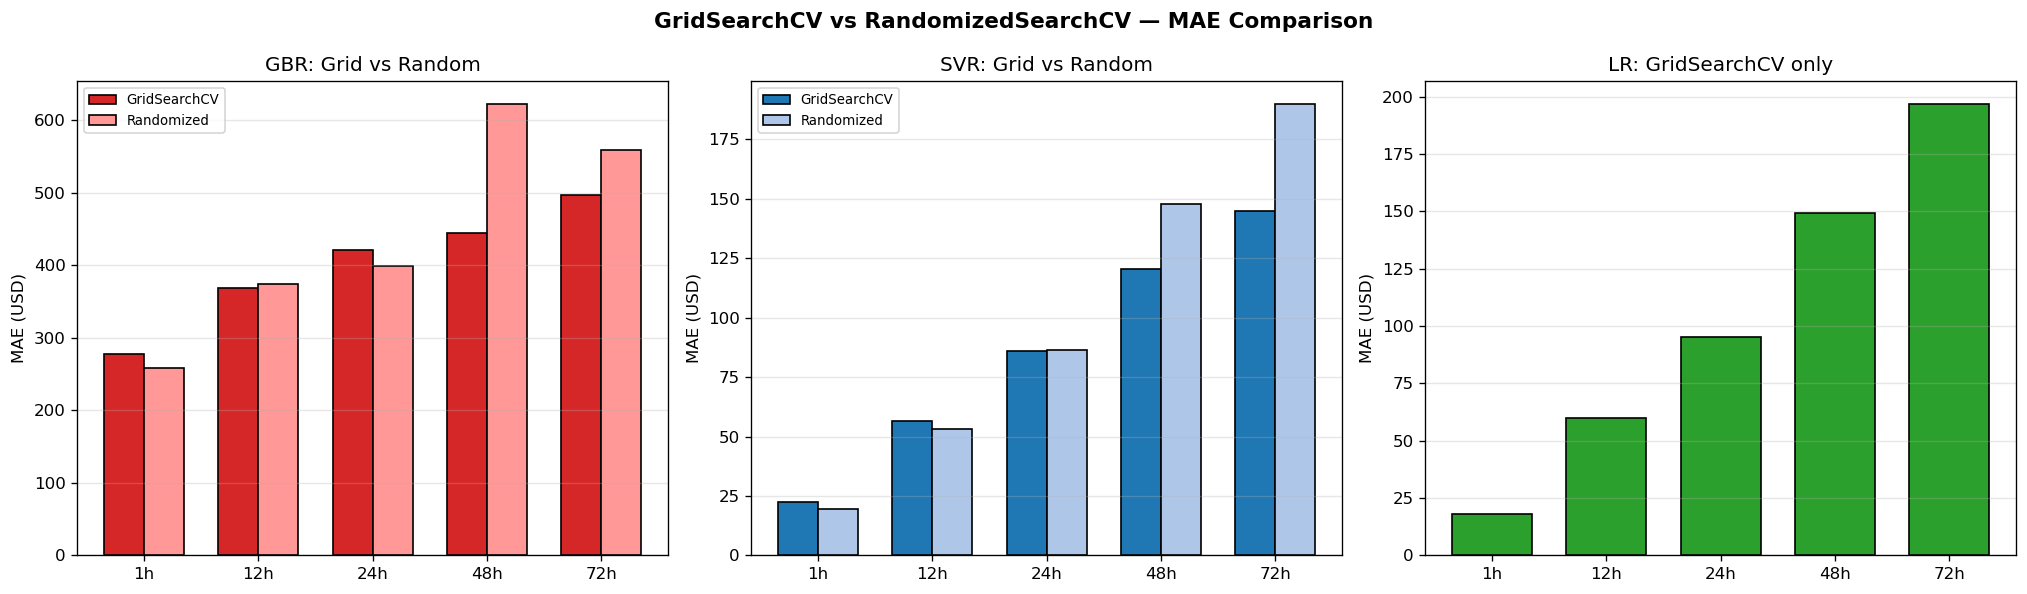

In [ ]:

# Plot 2: Grid vs Random — Side-by-side MAE comparison

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = np.arange(len(HORIZONS))
w = 0.35

# GBR
ax = axes[0]
gbg = [next((r["mae"] for r in all_grid if r["model_name"] == "gradient_boosting" and r["horizon"] == h), 0) for h in HORIZONS]
gbr_mae = [next((r["mae"] for r in all_gbr if r["horizon"] == h), 0) for h in HORIZONS]
ax.bar(x - w/2, gbg, w, label="GridSearchCV", color="#d62728", edgecolor="black")
ax.bar(x + w/2, gbr_mae, w, label="Randomized", color="#ff9896", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in HORIZONS])
ax.set_ylabel("MAE (USD)")
ax.set_title("GBR: Grid vs Random")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# SVR
ax = axes[1]
svg = [next((r["mae"] for r in all_grid if r["model_name"] == "svr" and r["horizon"] == h), 0) for h in HORIZONS]
svr_mae = [next((r["mae"] for r in all_svr if r["horizon"] == h), 0) for h in HORIZONS]
ax.bar(x - w/2, svg, w, label="GridSearchCV", color="#1f77b4", edgecolor="black")
ax.bar(x + w/2, svr_mae, w, label="Randomized", color="#aec7e8", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in HORIZONS])
ax.set_ylabel("MAE (USD)")
ax.set_title("SVR: Grid vs Random")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# LR — only GridSearchCV (no random done)
ax = axes[2]
lrg = [next((r["mae"] for r in all_grid if r["model_name"] == "linear_regression" and r["horizon"] == h), 0) for h in HORIZONS]
ax.bar(x, lrg, w * 2, color="#2ca02c", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in HORIZONS])
ax.set_ylabel("MAE (USD)")
ax.set_title("LR: GridSearchCV only")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("GridSearchCV vs RandomizedSearchCV — MAE Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

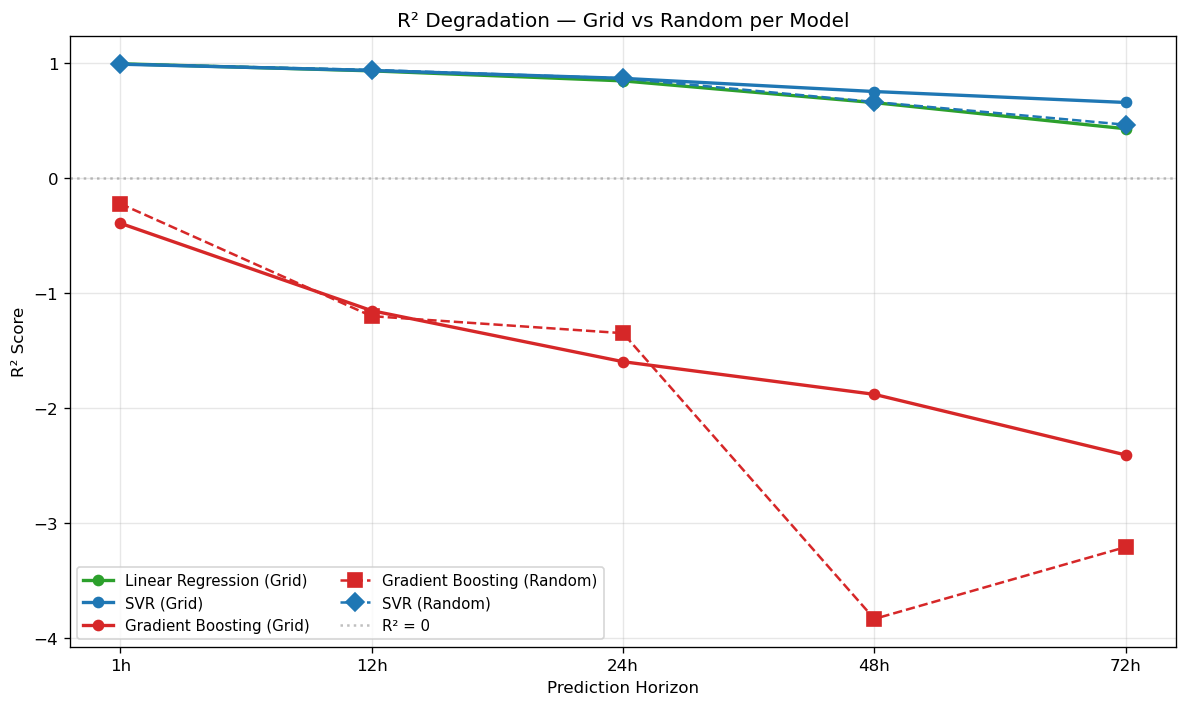

In [ ]:

# Plot 3: R\u00b2 degradation — semua model Grid + Random

fig, ax = plt.subplots(figsize=(10, 6))

# GridSearchCV lines
for model_key in ["linear_regression", "svr", "gradient_boosting"]:
    label = MODEL_LABELS[model_key]
    subset = df_all[df_all["Model"] == label]
    ax.plot(subset["Horizon"], subset["R\u00b2"], marker="o", linewidth=2,
            color=MODEL_COLORS[model_key], label=f"{label} (Grid)", linestyle="-")

# Randomized markers (GBR + SVR only)
for model_key, all_rand_list, marker, ls in [
    ("gradient_boosting", all_gbr, "s", "--"),
    ("svr", all_svr, "D", "--"),
]:
    label = MODEL_LABELS[model_key]
    xs, ys = [], []
    for r in all_rand_list:
        xs.append(f"{r['horizon']}h")
        ys.append(r["r2"])
    ax.plot(xs, ys, marker=marker, linewidth=1.5, linestyle=ls,
            color=MODEL_COLORS[model_key], label=f"{label} (Random)", markersize=8)

ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5, label="R\u00b2 = 0")
ax.set_xlabel("Prediction Horizon")
ax.set_ylabel("R\u00b2 Score")
ax.set_title("R\u00b2 Degradation — Grid vs Random per Model")
ax.legend(loc="lower left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# Summary

print("=" * 75)
print("  KEY TAKEAWAYS")
print("=" * 75)
print()
print(f"  Best 1h   : Linear Regression (MAE=${champions['1']['mae']:.2f}, R\u00b2={champions['1']['r2']:.4f})")
for h in [12, 24, 48, 72]:
    c = champions[str(h)]
    print(f"  Best {h}h  : {MODEL_LABELS[c['model']]:<20s} (MAE=${c['mae']:.2f}, R\u00b2={c['r2']:.4f})")
print()
print("  GBR        : FAILED all horizons (R\u00b2 < 0 even with RandomizedSearchCV)")
print("  SVR Random : Better at 1h-12h, WORSE at 48h-72h (overfit pada CV)")
print("  Degradation: All models degrade ~10\u00d7 from 1h to 72h")
print("  Key features: lag_3 (short-term), gold_dxy_ratio (all horizons)")
print()
print(f"  Files saved in: {RESULTS_DIR.resolve()}")
print(f"  Models saved in: {Path('models').resolve()}")
print("=" * 75)

  KEY TAKEAWAYS

  Best 1h   : Linear Regression (MAE=$18.16, R²=0.9919)
  Best 12h  : SVR                  (MAE=$56.42, R²=0.9334)
  Best 24h  : SVR                  (MAE=$86.17, R²=0.8652)
  Best 48h  : SVR                  (MAE=$120.63, R²=0.7505)
  Best 72h  : SVR                  (MAE=$144.76, R²=0.6555)

  GBR        : FAILED all horizons (R² < 0 even with RandomizedSearchCV)
  SVR Random : Better at 1h-12h, WORSE at 48h-72h (overfit pada CV)
  Degradation: All models degrade ~10× from 1h to 72h
  Key features: lag_3 (short-term), gold_dxy_ratio (all horizons)

  Files saved in: /home/fatih/kuliah-projek/Gold-Prediction-Big-Data-Kel3/eksperiment/results
  Models saved in: /home/fatih/kuliah-projek/Gold-Prediction-Big-Data-Kel3/eksperiment/models


  TREN DEGRADASI AKURASI — GridSearchCV Baseline


,Horizon,Linear Regression MAE,Linear Regression R²,SVR MAE,SVR R²,Gradient Boosting MAE,Gradient Boosting R²,Champion
0,1h,$18.16,0.9919,$22.39,0.9882,$277.68,-0.3941,Linear Regression
1,12h,$59.94,0.9302,$56.42,0.9334,$368.49,-1.1535,SVR
2,24h,$95.41,0.8431,$86.17,0.8652,$420.66,-1.5972,SVR
3,48h,$149.13,0.6541,$120.63,0.7505,$444.30,-1.8810,SVR
4,72h,$197.07,0.4271,$144.76,0.6555,$496.95,-2.4080,SVR



--- Degradation Factor (1h = baseline) ---
  Baseline (1h): LR MAE=$18.16, SVR MAE=$22.39
  Linear Regression       MAE: ×10.9  |  R²: -0.5648 drop
  SVR                     MAE: ×6.5  |  R²: -0.3327 drop
  Gradient Boosting       MAE: ×1.8  |  R²: -2.0139 drop


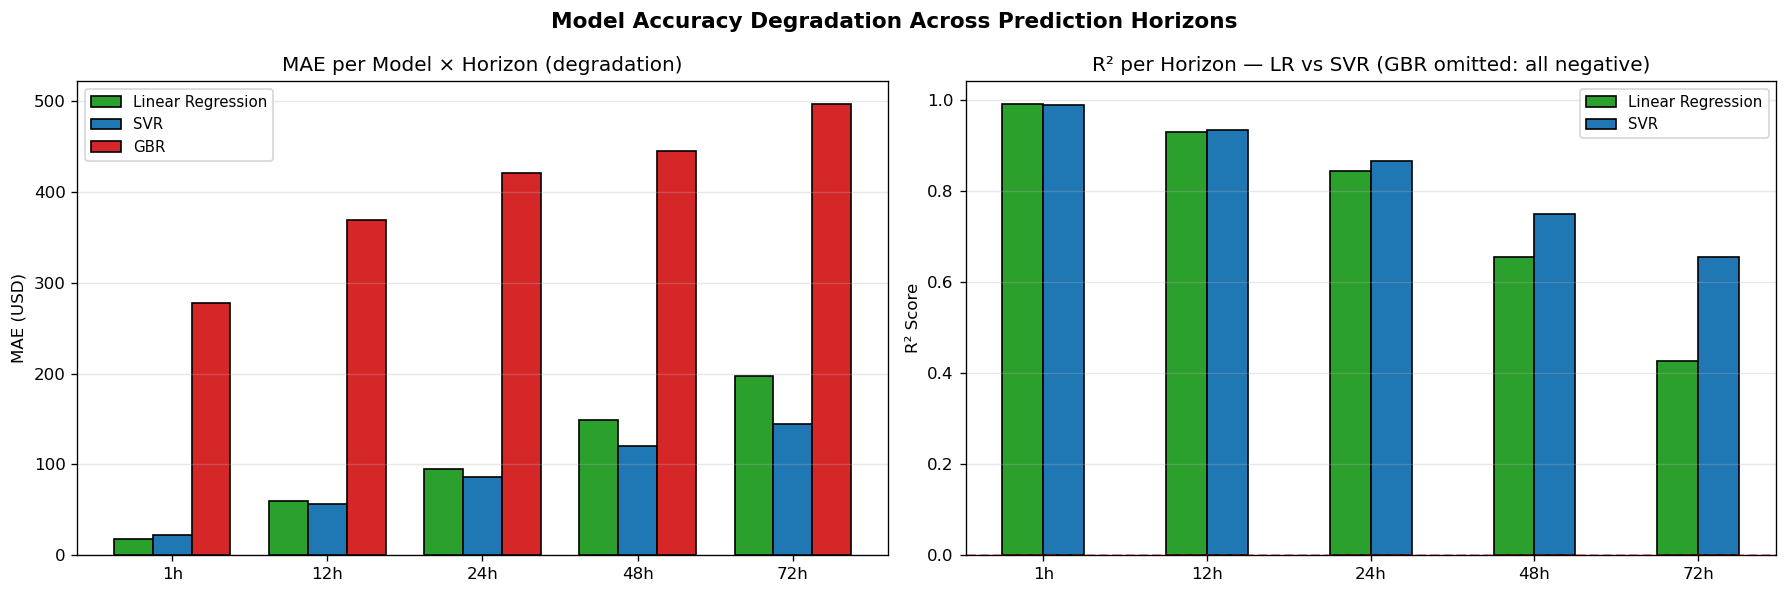

In [ ]:

# Cell 25: Accuracy Degradation Trend per Model

rows_deg = []
for h in HORIZONS:
    row = {"Horizon": f"{h}h"}
    for mk in ["linear_regression", "svr", "gradient_boosting"]:
        r = next((x for x in all_grid if x["model_name"] == mk and x["horizon"] == h), None)
        if r:
            row[f"{MODEL_LABELS[mk]} MAE"] = round(r["mae"], 2)
            row[f"{MODEL_LABELS[mk]} R\u00b2"] = round(r["r2"], 4)
    row["Champion"] = MODEL_LABELS[champions[str(h)]["model"]]
    rows_deg.append(row)

df_deg = pd.DataFrame(rows_deg)

print("=" * 100)
print("  TREN DEGRADASI AKURASI — GridSearchCV Baseline")
print("=" * 100)

display(
    df_deg.style
    .format({
        "Linear Regression MAE": "${:.2f}", "Linear Regression R\u00b2": "{:.4f}",
        "Gradient Boosting MAE": "${:.2f}", "Gradient Boosting R\u00b2": "{:.4f}",
        "SVR MAE": "${:.2f}", "SVR R\u00b2": "{:.4f}",
    })
    .set_caption("Akurasi (MAE & R\u00b2) per Horizon — Champion di kolom paling kanan")
)

# Degradation factor (1h baseline)
print()
print("--- Degradation Factor (1h = baseline) ---")
base = rows_deg[0]
print(f"  Baseline (1h): LR MAE=${base['Linear Regression MAE']:.2f}, SVR MAE=${base['SVR MAE']:.2f}")
last = rows_deg[-1]
for mk in ["Linear Regression", "SVR", "Gradient Boosting"]:
    factor = last[f"{mk} MAE"] / base[f"{mk} MAE"]
    r2_drop = last[f"{mk} R\u00b2"] - base[f"{mk} R\u00b2"]
    print(f"  {mk:<22s}  MAE: \u00d7{factor:.1f}  |  R\u00b2: {r2_drop:+.4f} drop")

# Bar chart: MAE degradation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(HORIZONS))
w = 0.25

lr_mae = [next((r["mae"] for r in all_grid if r["model_name"] == "linear_regression" and r["horizon"] == h), 0) for h in HORIZONS]
svr_mae_vals = [next((r["mae"] for r in all_grid if r["model_name"] == "svr" and r["horizon"] == h), 0) for h in HORIZONS]
gbr_mae_vals = [next((r["mae"] for r in all_grid if r["model_name"] == "gradient_boosting" and r["horizon"] == h), 0) for h in HORIZONS]

ax1.bar(x - w, lr_mae, w, label="Linear Regression", color="#2ca02c", edgecolor="black")
ax1.bar(x, svr_mae_vals, w, label="SVR", color="#1f77b4", edgecolor="black")
ax1.bar(x + w, gbr_mae_vals, w, label="GBR", color="#d62728", edgecolor="black")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{h}h" for h in HORIZONS])
ax1.set_ylabel("MAE (USD)")
ax1.set_title("MAE per Model \u00d7 Horizon (degradation)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis="y")

lr_r2 = [next((r["r2"] for r in all_grid if r["model_name"] == "linear_regression" and r["horizon"] == h), 0) for h in HORIZONS]
svr_r2 = [next((r["r2"] for r in all_grid if r["model_name"] == "svr" and r["horizon"] == h), 0) for h in HORIZONS]

ax2.bar(x - w/2, lr_r2, w, label="Linear Regression", color="#2ca02c", edgecolor="black")
ax2.bar(x + w/2, svr_r2, w, label="SVR", color="#1f77b4", edgecolor="black")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels([f"{h}h" for h in HORIZONS])
ax2.set_ylabel("R\u00b2 Score")
ax2.set_title("R\u00b2 per Horizon — LR vs SVR (GBR omitted: all negative)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle("Model Accuracy Degradation Across Prediction Horizons", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:

# Cell 26: Rekomendasi per Horizon — best model, params, features

rec_rows = []
for h in HORIZONS:
    c = champions[str(h)]
    best_model_key = c["model"]

    # Best hyperparams dari champion
    best_params = c["best_params"]
    if best_params:
        params_str = ", ".join(f"{k}={v}" for k, v in best_params.items())
    else:
        params_str = "No tuning (default)"

    # Top-3 features from GBR Random (most exploration of features)
    top3_str = "—"
    for r in all_gbr:
        if r["horizon"] == h and r.get("feature_importance"):
            imps = r["feature_importance"]
            top3 = sorted(imps.items(), key=lambda x: x[1], reverse=True)[:3]
            top3_str = ", ".join(f"{feat} ({imp:.1%})" for feat, imp in top3)
            # remove the "%" formatting issue — use proportion as decimal
            top3_str = ", ".join(f"{feat}" for feat, _ in top3)
            break

    # Tuning method
    if best_model_key == "linear_regression":
        tuning = "None"
    else:
        tuning = "GridSearchCV (neg RMSE)"

    rec_rows.append({
        "Horizon": f"{h}h",
        "Best Model": MODEL_LABELS[best_model_key],
        "Hyperparameters": params_str,
        "Top-3 Features": top3_str,
        "MAE": round(c["mae"], 2),
        "R\u00b2": round(c["r2"], 4),
        "RMSE": round(c["rmse"], 2),
        "Tuning": tuning,
    })

df_rec = pd.DataFrame(rec_rows)

print("=" * 120)
print("  TABLE — REKOMENDASI PER HORIZON: Model, Hyperparams, Top Features")
print("=" * 120)

display(
    df_rec.style
    .format({"MAE": "${:.2f}", "RMSE": "${:.2f}", "R\u00b2": "{:.4f}"})
    .set_caption("Best model + best hyperparams + most predictive features — per horizon")
)

# Additional insight: feature importance shift per horizon
print()
print("--- Feature Importance Shift per Horizon (from GBR Random) ---")
for h in HORIZONS:
    for r in all_gbr:
        if r["horizon"] == h and r.get("feature_importance"):
            imps = r["feature_importance"]
            top3 = sorted(imps.items(), key=lambda x: x[1], reverse=True)[:3]
            feat_str = "  |  ".join(f"{feat}: {imp:.1%}" for feat, imp in top3)
            print(f"  h={h:>2d}:  {feat_str}")
            break

print()
print("Key insight:")
print("  h=1h  : Short-term memory (lag_3 dominates 76%)")
print("  h=12h+: Gold/DXY ratio becomes dominant feature")
print("  h=72h : Long lags (24h, 72h) replace short lags — model needs deeper history")

  TABLE — REKOMENDASI PER HORIZON: Model, Hyperparams, Top Features


,Horizon,Best Model,Hyperparameters,Top-3 Features,MAE,R²,RMSE,Tuning
0,1h,Linear Regression,No tuning (default),"lag_3, gold_dxy_ratio, rolling_mean_24",$18.16,0.9919,$28.41,None
1,12h,SVR,"C=1, epsilon=0.5, gamma=0.001, kernel=linear","gold_dxy_ratio, rolling_mean_168, lag_3",$56.42,0.9334,$81.36,GridSearchCV (neg RMSE)
2,24h,SVR,"C=50, epsilon=0.1, gamma=0.001, kernel=linear","gold_dxy_ratio, rolling_mean_168, lag_3",$86.17,0.8652,$115.74,GridSearchCV (neg RMSE)
3,48h,SVR,"C=1, epsilon=0.5, gamma=0.001, kernel=linear","lag_3, rolling_mean_168, gold_dxy_ratio",$120.63,0.7505,$157.53,GridSearchCV (neg RMSE)
4,72h,SVR,"C=1, epsilon=0.5, gamma=0.001, kernel=linear","lag_24, lag_72, rolling_mean_24",$144.76,0.6555,$185.15,GridSearchCV (neg RMSE)



--- Feature Importance Shift per Horizon (from GBR Random) ---
  h= 1:  lag_3: 76.1%  |  gold_dxy_ratio: 10.0%  |  rolling_mean_24: 9.8%
  h=12:  gold_dxy_ratio: 70.9%  |  rolling_mean_168: 19.4%  |  lag_3: 8.6%
  h=24:  gold_dxy_ratio: 62.8%  |  rolling_mean_168: 21.0%  |  lag_3: 14.6%
  h=48:  lag_3: 14.1%  |  rolling_mean_168: 13.1%  |  gold_dxy_ratio: 10.4%
  h=72:  lag_24: 39.2%  |  lag_72: 19.7%  |  rolling_mean_24: 10.9%

Key insight:
  h=1h  : Short-term memory (lag_3 dominates 76%)
  h=12h+: Gold/DXY ratio becomes dominant feature
  h=72h : Long lags (24h, 72h) replace short lags — model needs deeper history


In [ ]:

import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path("results")

# Load GridSearchCV results (latest.json = symlink ke file terbaru)
with open(RESULTS_DIR / "latest.json") as f:
    data_grid = json.load(f)

# Load GBR RandomizedSearchCV (untuk feature importance per horizon)
with open(RESULTS_DIR / "results_gbr_random_20260627_093439.json") as f:
    data_gbr_rand = json.load(f)

all_grid = data_grid["all_results"]
all_gbr = data_gbr_rand["all_results"]
champions = data_grid["champions"]

HORIZONS = [1, 12, 24, 48, 72]
HORIZON_LABELS = [f"{h}h" for h in HORIZONS]

MODEL_LABELS = {
    "linear_regression": "Linear Regression",
    "gradient_boosting": "Gradient Boosting",
    "svr": "SVR",
}
MODEL_KEYS = ["linear_regression", "svr", "gradient_boosting"]
MODEL_COLORS = {
    "linear_regression": "#2ca02c",
    "gradient_boosting": "#d62728",
    "svr": "#1f77b4",
}

print("Data loaded OK")
print(f"  all_grid: {len(all_grid)} results")
print(f"  all_gbr:  {len(all_gbr)} results")
print(f"  Champions: { {h: champions[str(h)]['model'] for h in HORIZONS} }")


Data loaded OK
  all_grid: 15 results
  all_gbr:  5 results
  Champions: {1: 'linear_regression', 12: 'svr', 24: 'svr', 48: 'svr', 72: 'svr'}


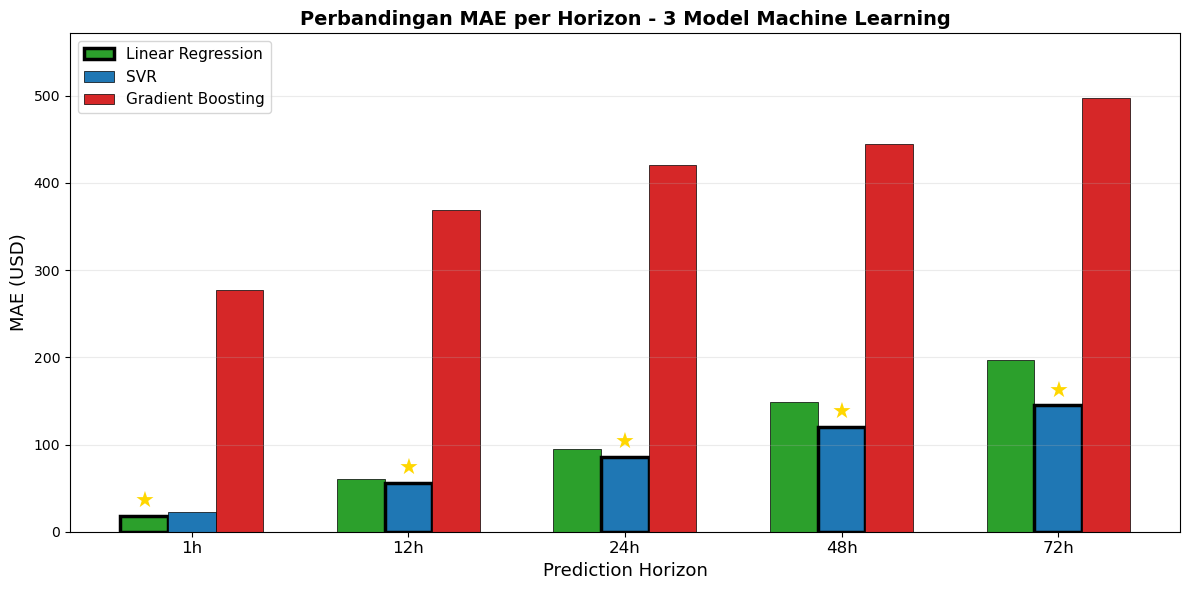

In [ ]:

#Grouped Bar Chart: MAE per Horizon × Model

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(HORIZONS))
width = 0.22
bar_data = {}
for mk in MODEL_KEYS:
    bar_data[mk] = [
        next((r["mae"] for r in all_grid
              if r["model_name"] == mk and r["horizon"] == h), 0)
        for h in HORIZONS
    ]

for i, mk in enumerate(MODEL_KEYS):
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset, bar_data[mk], width,
        label=MODEL_LABELS[mk],
        color=MODEL_COLORS[mk],
        edgecolor="black",
        linewidth=0.5,
    )
    # Highlight champion bar with bold border + value label
    for j, h in enumerate(HORIZONS):
        if champions[str(h)]["model"] == mk:
            bars[j].set_edgecolor("black")
            bars[j].set_linewidth(2.5)
            ax.text(
                x[j] + offset, bar_data[mk][j] + 10,
                "★", ha="center", fontsize=16, color="gold",
                fontweight="bold",
            )

ax.set_xticks(x)
ax.set_xticklabels(HORIZON_LABELS, fontsize=12)
ax.set_xlabel("Prediction Horizon", fontsize=13)
ax.set_ylabel("MAE (USD)", fontsize=13)
ax.set_title("Perbandingan MAE per Horizon - 3 Model Machine Learning", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.25, axis="y")
ax.set_ylim(0, max(bar_data["gradient_boosting"]) * 1.15)

plt.tight_layout()
plt.show()


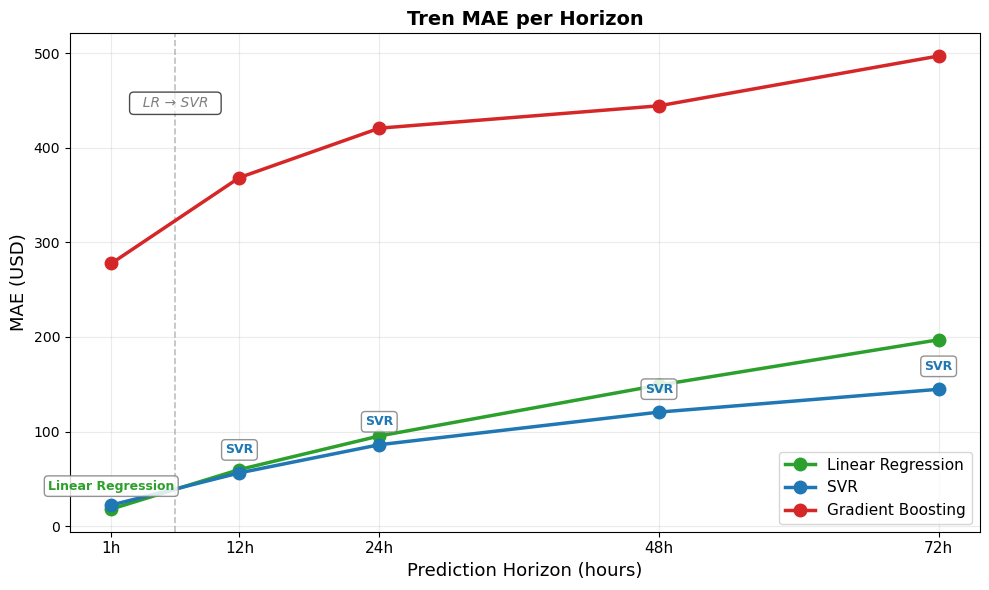

In [ ]:

# Line Chart: MAE vs Horizon + Cross-over Annotation

fig, ax = plt.subplots(figsize=(10, 6))

for mk in MODEL_KEYS:
    mae_vals = [
        next((r["mae"] for r in all_grid
              if r["model_name"] == mk and r["horizon"] == h), 0)
        for h in HORIZONS
    ]
    ax.plot(
        HORIZONS, mae_vals,
        marker="o", linewidth=2.5, markersize=9,
        color=MODEL_COLORS[mk],
        label=MODEL_LABELS[mk],
        zorder=3,
    )

# Annotate champion name at each horizon point
for i, h in enumerate(HORIZONS):
    champ_key = champions[str(h)]["model"]
    champ_mae = champions[str(h)]["mae"]
    ax.annotate(
        MODEL_LABELS[champ_key],
        (h, champ_mae),
        textcoords="offset points",
        xytext=(0, 14),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=MODEL_COLORS[champ_key],
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="gray"),
    )

# Vertical dashed line at cross-over (LR → SVR between 1h and 12h)
ax.axvline(x=6.5, color="gray", linestyle="--", alpha=0.5, linewidth=1.2)
ax.text(
    6.5, ax.get_ylim()[1] * 0.85,
    "  LR → SVR  ",
    ha="center", fontsize=10, fontstyle="italic",
    color="gray",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)

ax.set_xlabel("Prediction Horizon (hours)", fontsize=13)
ax.set_ylabel("MAE (USD)", fontsize=13)
ax.set_title(
    "Tren MAE per Horizon",
    fontsize=14, fontweight="bold",
)
ax.set_xticks(HORIZONS)
ax.set_xticklabels(HORIZON_LABELS, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


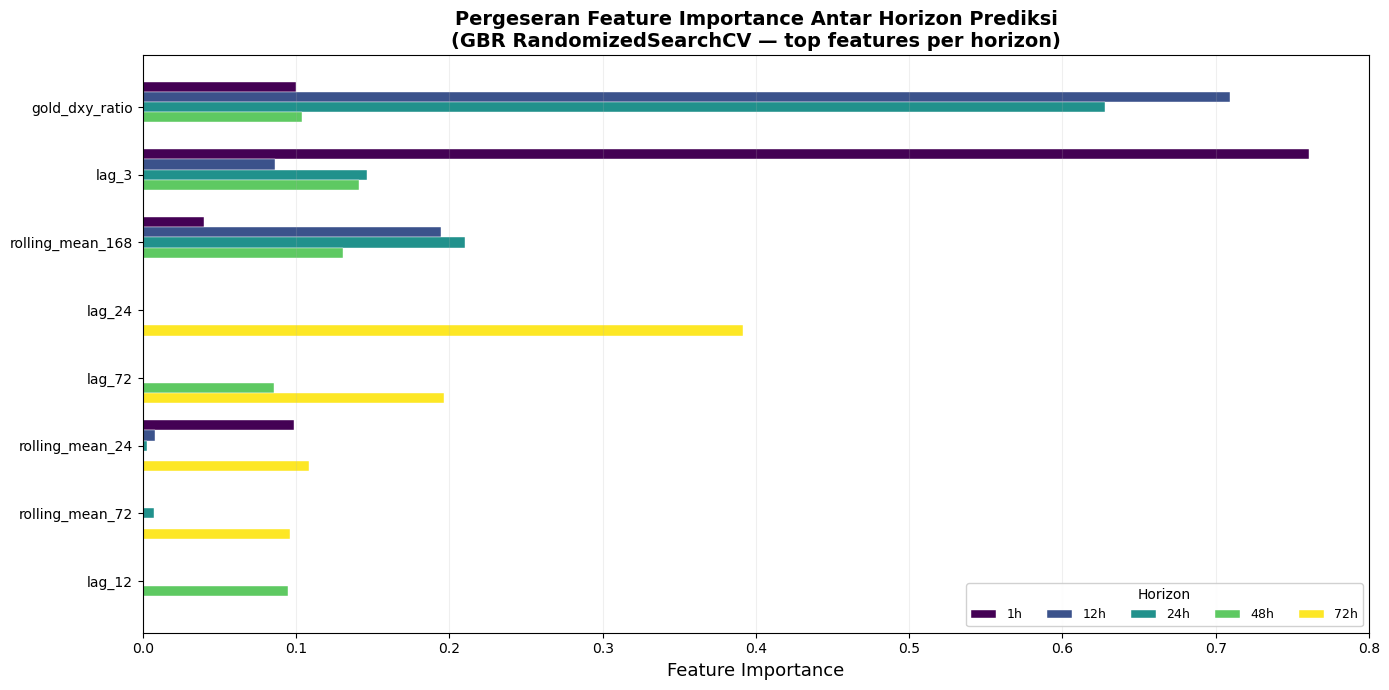


Key insight:
  h=1h  : Short-term memory dominates (lag_3)
  h=12-48h : Gold/DXY ratio + rolling mean become primary
  h=72h : Long lags (lag_24, lag_72) replace short lags — model needs deeper history


In [ ]:

# Cell C — Feature Importance Shift Across Horizons


from collections import defaultdict

# Kumpulkan top-5 features per horizon dari GBR Randomized
# (GBR digunakan sebagai proxy feature importance karena memiliki
#  feature_importances_ atribut; LR dan SVR Linear tidak memilikinya)
all_top_features = set()
horizon_imps = defaultdict(dict)

for r in all_gbr:
    h = r["horizon"]
    imps = r.get("feature_importance", {})
    if not imps:
        continue
    sorted_imps = sorted(imps.items(), key=lambda x: x[1], reverse=True)
    for feat, imp in sorted_imps[:5]:
        all_top_features.add(feat)
        horizon_imps[h][feat] = imp

# Ranking fitur berdasarkan total importance (untuk memilih top-N)
feature_scores = {
    f: sum(horizon_imps[h].get(f, 0) for h in HORIZONS)
    for f in all_top_features
}
top_features = sorted(feature_scores, key=feature_scores.get, reverse=True)[:8]

# ── Plot: grouped horizontal bar ──
fig, ax = plt.subplots(figsize=(14, 7))

y_pos = np.arange(len(top_features))
n_horizons = len(HORIZONS)
bar_height = 0.15
cmap = plt.cm.viridis
horizon_colors = [cmap(i / (n_horizons - 1)) for i in range(n_horizons)]

for i, h in enumerate(HORIZONS):
    values = [horizon_imps[h].get(f, 0) for f in top_features]
    offset = (i - n_horizons / 2 + 0.5) * bar_height
    bars = ax.barh(
        y_pos + offset, values, bar_height,
        label=f"{h}h",
        color=horizon_colors[i],
        edgecolor="white",
        linewidth=0.3,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance", fontsize=13)
ax.set_title(
    "Pergeseran Feature Importance Antar Horizon Prediksi\n"
    "(GBR RandomizedSearchCV — top features per horizon)",
    fontsize=14, fontweight="bold",
)
ax.legend(
    title="Horizon", title_fontsize=10, fontsize=9,
    loc="lower right", ncol=5, framealpha=0.9,
)
ax.grid(True, alpha=0.2, axis="x")
ax.set_xlim(0, 0.8)

plt.tight_layout()
plt.show()

# ── Insight teks ──
print()
print("Key insight:")
print("  h=1h  : Short-term memory dominates (lag_3)")
print("  h=12-48h : Gold/DXY ratio + rolling mean become primary")
print("  h=72h : Long lags (lag_24, lag_72) replace short lags — model needs deeper history")


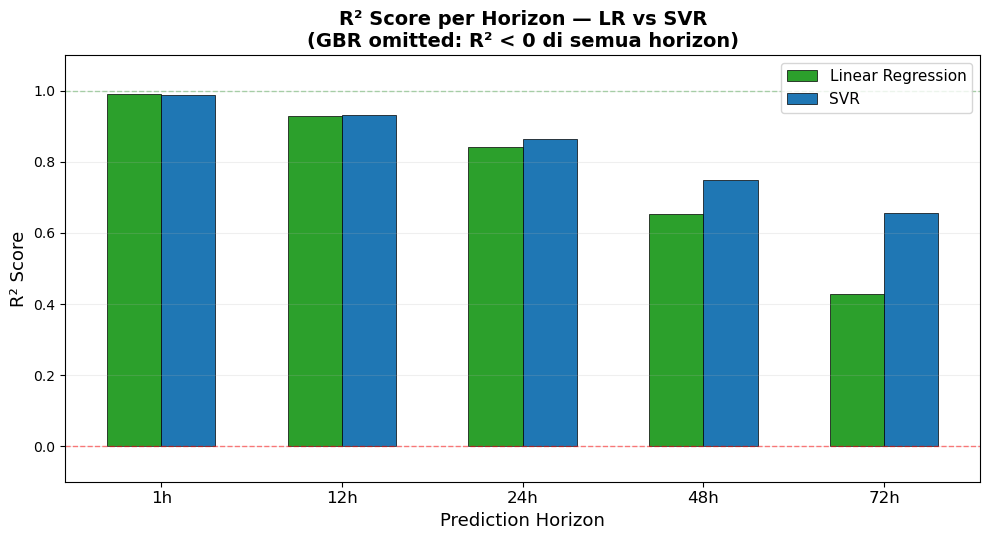

In [ ]:

# Cell D — R² per Horizon per Model

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(HORIZONS))
width = 0.3

r2_data = {}
for mk in ["linear_regression", "svr"]:
    r2_data[mk] = [
        next((r["r2"] for r in all_grid
              if r["model_name"] == mk and r["horizon"] == h), 0)
        for h in HORIZONS
    ]

for i, mk in enumerate(["linear_regression", "svr"]):
    offset = (i - 0.5) * width
    ax.bar(
        x + offset, r2_data[mk], width,
        label=MODEL_LABELS[mk],
        color=MODEL_COLORS[mk],
        edgecolor="black",
        linewidth=0.5,
    )

# Reference line
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(y=1, color="green", linestyle="--", alpha=0.3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(HORIZON_LABELS, fontsize=12)
ax.set_xlabel("Prediction Horizon", fontsize=13)
ax.set_ylabel("R² Score", fontsize=13)
ax.set_title(
    "R² Score per Horizon — LR vs SVR\n"
    "(GBR omitted: R² < 0 di semua horizon)",
    fontsize=14, fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis="y")
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()


In [ ]:

# Cell E — Champion Summary Table

print("=" * 80)
print("  CHAMPION SUMMARY — GridSearchCV (MAE sebagai kriteria utama)")
print("=" * 80)
print()

rows = []
for h in HORIZONS:
    c = champions[str(h)]
    rows.append({
        "Horizon": f"{h}h",
        "Champion Model": MODEL_LABELS[c["model"]],
        "MAE (USD)": f"${c['mae']:.2f}",
        "RMSE (USD)": f"${c['rmse']:.2f}",
        "R²": f"{c['r2']:.4f}",
    })

df_champ = pd.DataFrame(rows)

# Style
styled = (
    df_champ.style
    .set_caption("Model Champion per Horizon — GridSearchCV")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {
            "selector": "caption",
            "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left")],
        },
        {
            "selector": "th",
            "props": [("background-color", "#0e0505"), ("font-weight", "bold")],
        },
    ])
)

# Highlight LR di h=1 (outlier pattern)
def highlight_lr(row):
    if row["Champion Model"] == "Linear Regression":
        return ["background-color: #ffe6e6"] * len(row)
    return [""] * len(row)

styled = styled.apply(highlight_lr, axis=1)
display(styled)


  CHAMPION SUMMARY — GridSearchCV (MAE sebagai kriteria utama)



,Horizon,Champion Model,MAE (USD),RMSE (USD),R²
0,1h,Linear Regression,$18.16,$28.41,0.9919
1,12h,SVR,$56.42,$81.36,0.9334
2,24h,SVR,$86.17,$115.74,0.8652
3,48h,SVR,$120.63,$157.53,0.7505
4,72h,SVR,$144.76,$185.15,0.6555



--- Ringkasan Temuan (3.4.3.5) ---
  1. Horizon 1h : Linear Regression adalah champion (MAE=$18.16)
     → Pola harga jangka pendek dominan linear/persisten
  2. Horizon 12h-72h : SVR konsisten menjadi champion (MAE $56.42–$144.76)
     → Hubungan makroekonomi-harga emas bersifat non-linear di horizon panjang
  3. GBR gagal di semua horizon (R² negatif) — overfit pada struktur time-series
  4. Degradasi akurasi: MAE LR naik ×10.9 dari 1h ke 72h; SVR naik ×6.5
